## **Air Traffic Trend Prediction using RNN, LSTM and GRU**

### **Project Objective**

The goal of this project is to predict air traffic trends and flight-related patterns using deep learning models:

* RNN
* GRU
* LSTM

The project uses time-series flight analytics data to learn patterns such as:

* Flight delays
* Traffic trends
* Route activity
* Passenger movement

## **Importing library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, LSTM

# **Load Dataset**

In [ ]:
df = pd.read_csv("//content/Flight_data.csv")

# Select Important Columns

In [ ]:
df = df[['Departure Date',
         'Flight Duration',
         'Delay Minutes',
         'Route']]

# **Convert Date Column**

In [ ]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'])

df['Year'] = df['Departure Date'].dt.year
df['Month'] = df['Departure Date'].dt.month
df['Day'] = df['Departure Date'].dt.day

# **Encode Route Column**

In [ ]:
encoder = LabelEncoder()

df['Route'] = encoder.fit_transform(df['Route'])

## **Handle Missing Values**

In [ ]:
df = df.dropna()

# Define Features and Target

In [ ]:
X = df[['Flight Duration',
        'Route',
        'Year',
        'Month',
        'Day']]

y = df['Delay Minutes']

## **Normalize Data**

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(
    np.array(y).reshape(-1,1)
)

## Create Sequences

In [ ]:
sequence_length = 10

X_seq = []
y_seq = []

for i in range(sequence_length, len(X_scaled)):
    X_seq.append(X_scaled[i-sequence_length:i])
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

## Train Test Split

In [ ]:
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

## Build RNN Model

In [ ]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(
    64,
    input_shape=(X_train.shape[1],
                 X_train.shape[2])
))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4710
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1661
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2188
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1300
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0887
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1060
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1055
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0760
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0570 
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0607
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0609
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0518
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0470
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0475
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0472
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms

## Build GRU Model

In [ ]:
gru_model = Sequential()

gru_model.add(GRU(
    64,
    input_shape=(X_train.shape[1],
                 X_train.shape[2])
))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1850
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0855
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0739
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0971
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0934
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0757
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0694
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0716
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0736
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0722
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0689
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0686
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0692
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0716
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0701
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━

## Build LSTM Mode

In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    64,
    input_shape=(X_train.shape[1],
                 X_train.shape[2])
))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.2641
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1242
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0759
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0949
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0936
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0771
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0734
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0756
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0767
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0756
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0734
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0722
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0723
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0729
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0737
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━

## Predictions

In [ ]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


## Model Evaluation

In [ ]:
rnn_mse = mean_squared_error(y_test, rnn_pred)
gru_mse = mean_squared_error(y_test, gru_pred)
lstm_mse = mean_squared_error(y_test, lstm_pred)

print("RNN MSE:", rnn_mse)
print("GRU MSE:", gru_mse)
print("LSTM MSE:", lstm_mse)

RNN MSE: 0.11454442725740296
GRU MSE: 0.0957762010595235
LSTM MSE: 0.10393390379936969


## Visualization

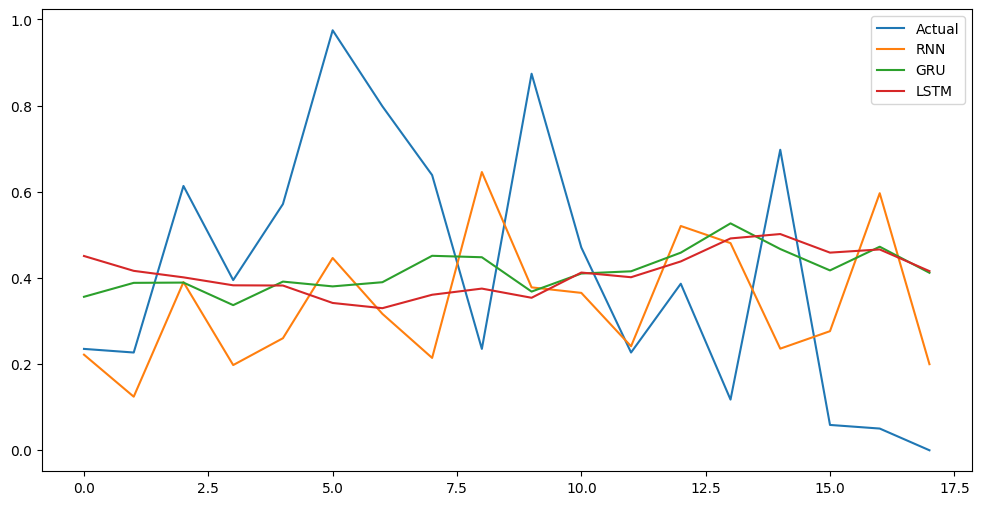

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')

plt.plot(rnn_pred, label='RNN')
plt.plot(gru_pred, label='GRU')
plt.plot(lstm_pred, label='LSTM')

plt.legend()
plt.show()